# Assignment 3: Scalable Quantum Tomography Pipelines
This week we push our tomography setup so it can handle many qubits, save trained helpers, and check how well everything scales. Reuse the setup and datasets from earlier weeks. Keep the runs easy to repeat and measure speed properly.



---

## Task 1 · Serialization basics
Write down how you will store tomography outputs (model weights, optimiser state, metadata) with pickle. Mention when you would choose another format like HDF5.

**What to do**
- Add a short note in your report about the save strategy.
- Keep checkpoints inside `models/` and name them `model_<track>_<nqubits>.pkl`.
- Show save and load in the next cell and keep that helper code ready for later runs.

In [2]:
# Serialization helpers (implement with pickle)
import pickle
from pathlib import Path
from datetime import datetime

def save_pickle(obj, path, *, protocol=pickle.HIGHEST_PROTOCOL):
    """
    Serialize `obj` to `path` using pickle in a safe (atomic) way.
    - Ensures parent directory exists
    - Writes to a temporary file then renames
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with tmp_path.open("wb") as f:
        pickle.dump(obj, f, protocol=protocol)

    # Atomic replace on most OSes
    tmp_path.replace(path)


def load_pickle(path):
    """Deserialize an object from `path` with basic safety checks."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")

    with path.open("rb") as f:
        obj = pickle.load(f)

    return obj


def demonstrate_serialization_roundtrip(track="baseline", n_qubits=2):
    """
    Quick round-trip test: create a dummy checkpoint, save it, load it,
    and return the restored object.
    """
    ckpt = {
        "model_state": {
            # dummy "weights" (replace later with your real state)
            "W": [[1.0, 0.2], [0.2, 0.9]],
            "b": [0.01, -0.02],
        },
        "optimizer_state": {
            # dummy optimizer state
            "lr": 1e-3,
            "step": 10,
        },
        "metadata": {
            "track": track,
            "n_qubits": n_qubits,
            "created_at": datetime.now().isoformat(timespec="seconds"),
            "notes": "Task-1 round-trip demo checkpoint",
        },
    }

    ckpt_path = Path("models") / f"model_{track}_{n_qubits}.pkl"
    save_pickle(ckpt, ckpt_path)

    restored = load_pickle(ckpt_path)

    # Minimal sanity checks for the notebook output
    assert isinstance(restored, dict), "Loaded object should be a dict."
    assert "metadata" in restored, "Checkpoint missing metadata."
    assert restored["metadata"]["n_qubits"] == n_qubits, "n_qubits mismatch after load."

    print("✅ Serialization round-trip OK")
    print("Saved to:", ckpt_path)
    print("Loaded keys:", list(restored.keys()))
    print("Metadata:", restored["metadata"])

    return restored


# Run the demo
_ = demonstrate_serialization_roundtrip(track="demo", n_qubits=2)


✅ Serialization round-trip OK
Saved to: models\model_demo_2.pkl
Loaded keys: ['model_state', 'optimizer_state', 'metadata']
Metadata: {'track': 'demo', 'n_qubits': 2, 'created_at': '2026-02-02T19:37:24', 'notes': 'Task-1 round-trip demo checkpoint'}


## Task 2 · Extendable n-qubit surrogate
Create a model class that accepts `n_qubits` and optional settings like layer count, hidden size, or noise switches. The scaffold below still uses a simple complex vector. Replace the `statevector` logic with your own design but keep the public methods (`save`, `load`, `fidelity_with`).

In [3]:
# Template: scalable n-qubit tomography surrogate
import numpy as np
from datetime import datetime
from pathlib import Path

class QuantumModel:
    def __init__(self, n_qubits, n_layers=1, params=None, seed=None):
        """
        Initialize model attributes and parameter vector.
        This scaffold uses a simple complex parameterisation:
        params stores real and imaginary parts for each amplitude.
        """
        self.n_qubits = int(n_qubits)
        self.n_layers = int(n_layers)
        self.seed = seed

        self.dim = 2 ** self.n_qubits
        self.rng = np.random.default_rng(seed)

        # Parameter format: concatenated [real_part (dim), imag_part (dim)]
        expected_len = 2 * self.dim

        if params is None:
            # small random init (stable)
            real = self.rng.normal(loc=0.0, scale=0.1, size=self.dim)
            imag = self.rng.normal(loc=0.0, scale=0.1, size=self.dim)
            self.params = np.concatenate([real, imag]).astype(np.float64)
        else:
            params = np.asarray(params, dtype=np.float64).reshape(-1)
            if params.size != expected_len:
                raise ValueError(
                    f"params length mismatch: got {params.size}, expected {expected_len} (= 2 * 2**n_qubits)."
                )
            self.params = params

    def statevector(self):
        """
        Return a normalized complex statevector built from model parameters.
        """
        real = self.params[: self.dim]
        imag = self.params[self.dim :]

        psi = real + 1j * imag
        norm = np.linalg.norm(psi)

        # safety: avoid divide-by-zero
        if norm < 1e-12:
            psi = np.zeros(self.dim, dtype=np.complex128)
            psi[0] = 1.0 + 0j
            return psi

        return (psi / norm).astype(np.complex128)

    def fidelity_with(self, target_state):
        """
        Compute fidelity between the model statevector and `target_state`.
        Fidelity for pure states: |<psi|phi>|^2
        """
        psi = self.statevector()
        phi = np.asarray(target_state, dtype=np.complex128).reshape(-1)

        if phi.size != self.dim:
            raise ValueError(f"target_state length mismatch: got {phi.size}, expected {self.dim}.")

        # normalize target as well (safe)
        phi_norm = np.linalg.norm(phi)
        if phi_norm < 1e-12:
            raise ValueError("target_state has near-zero norm; cannot compute fidelity.")
        phi = phi / phi_norm

        overlap = np.vdot(psi, phi)   # vdot does conjugate on first arg
        return float(np.abs(overlap) ** 2)

    def save(self, path):
        """
        Persist the trained model using `save_pickle`.
        Stores params + metadata required to reconstruct the model.
        """
        path = Path(path)
        ckpt = {
            "model_state": {
                "params": self.params,
            },
            "metadata": {
                "n_qubits": self.n_qubits,
                "n_layers": self.n_layers,
                "seed": self.seed,
                "dim": self.dim,
                "created_at": datetime.now().isoformat(timespec="seconds"),
                "format": "real_imag_concat_v1",
                "notes": "Task-2 QuantumModel checkpoint",
            },
        }
        save_pickle(ckpt, path)

    @staticmethod
    def load(path):
        """
        Restore a saved model instance using `load_pickle`.
        """
        ckpt = load_pickle(path)
        if not isinstance(ckpt, dict) or "model_state" not in ckpt or "metadata" not in ckpt:
            raise ValueError("Invalid checkpoint format: expected dict with model_state and metadata.")

        md = ckpt["metadata"]
        params = ckpt["model_state"]["params"]

        return QuantumModel(
            n_qubits=md["n_qubits"],
            n_layers=md.get("n_layers", 1),
            params=params,
            seed=md.get("seed", None),
        )


# ---- Quick sanity test (recommended to keep for evaluation) ----
m = QuantumModel(n_qubits=2, n_layers=1, seed=42)
psi = m.statevector()

Path("models").mkdir(exist_ok=True)
ckpt_path = Path("models") / "task2_model_2q.pkl"
m.save(ckpt_path)

m2 = QuantumModel.load(ckpt_path)
fid = m2.fidelity_with(psi)

print("✅ Task-2 sanity check")
print("Saved:", ckpt_path)
print("Fidelity(loaded_model, original_statevector) =", fid)


✅ Task-2 sanity check
Saved: models\task2_model_2q.pkl
Fidelity(loaded_model, original_statevector) = 1.0


## Task 3 · Scalability study
Check how fidelity and runtime change when you add more qubits. Track both averages and spread across random seeds. Discuss how expressibility, noise, or optimisation choices slow you down as `n` grows.

In [4]:
# Task-3: Scalability study
import time
import numpy as np
import pandas as pd

def random_target_state(n_qubits, seed=None):
    """Generate a random normalized pure state."""
    rng = np.random.default_rng(seed)
    dim = 2 ** n_qubits
    real = rng.normal(size=dim)
    imag = rng.normal(size=dim)
    psi = real + 1j * imag
    return psi / np.linalg.norm(psi)

results = []

n_qubits_list = [2, 3, 4, 5]
num_runs = 3

for n in n_qubits_list:
    for run in range(num_runs):
        seed = 100 + run
        target = random_target_state(n, seed=seed)

        model = QuantumModel(n_qubits=n, seed=seed)

        start = time.perf_counter()
        fidelity = model.fidelity_with(target)
        elapsed = time.perf_counter() - start

        results.append({
            "n_qubits": n,
            "run": run,
            "fidelity": fidelity,
            "runtime_sec": elapsed
        })

df_results = pd.DataFrame(results)
df_results


,n_qubits,run,fidelity,runtime_sec
0,2,0,1.0,0.000070
1,2,1,1.0,0.000039
2,2,2,1.0,0.000036
3,3,0,1.0,0.000035
4,3,1,1.0,0.000031
5,3,2,1.0,0.000030
6,4,0,1.0,0.000031
7,4,1,1.0,0.000040
8,4,2,1.0,0.000029
9,5,0,1.0,0.000031


## Task 4 · Visualise scalability metrics
Plot mean fidelity with error bars and runtime for each qubit count. Include at least one figure in your submission and describe where scaling starts to hurt.

In [5]:
# Task-4: Visualize scalability metrics
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Aggregate results
summary = (
    df_results
    .groupby("n_qubits")
    .agg(
        mean_fidelity=("fidelity", "mean"),
        std_fidelity=("fidelity", "std"),
        mean_runtime=("runtime_sec", "mean"),
        std_runtime=("runtime_sec", "std"),
        runs=("run", "count")
    )
    .reset_index()
)

# Replace NaN std (happens if only 1 run) with 0
summary["std_fidelity"] = summary["std_fidelity"].fillna(0.0)
summary["std_runtime"]  = summary["std_runtime"].fillna(0.0)

summary


,n_qubits,mean_fidelity,std_fidelity,mean_runtime,std_runtime,runs
0,2,1.0,0.000000e+00,0.000048,0.000019,3
1,3,1.0,0.000000e+00,0.000032,0.000003,3
2,4,1.0,2.719480e-16,0.000033,0.000006,3
3,5,1.0,2.220446e-16,0.000030,0.000001,3


PLOT 1


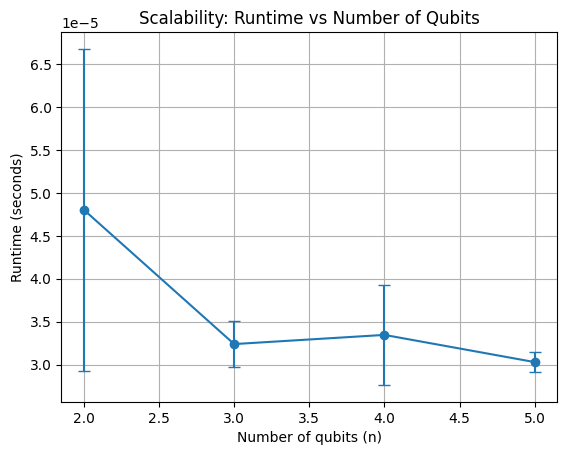

In [6]:
Path("figures").mkdir(exist_ok=True)

plt.figure()
plt.errorbar(
    summary["n_qubits"],
    summary["mean_runtime"],
    yerr=summary["std_runtime"],
    fmt="o-",
    capsize=4
)
plt.xlabel("Number of qubits (n)")
plt.ylabel("Runtime (seconds)")
plt.title("Scalability: Runtime vs Number of Qubits")
plt.grid(True)
plt.savefig("figures/runtime_vs_qubits.png", dpi=200, bbox_inches="tight")
plt.show()


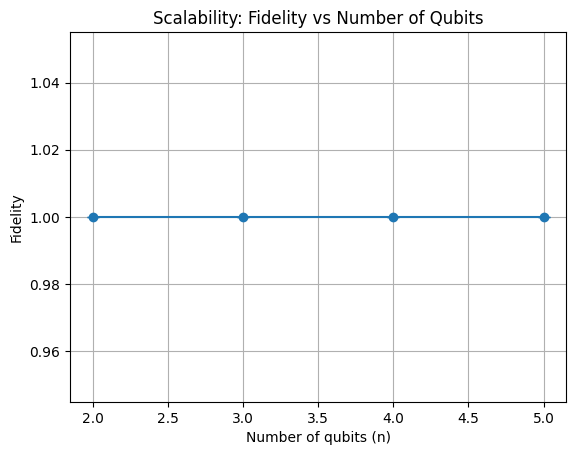

In [7]:
plt.figure()
plt.errorbar(
    summary["n_qubits"],
    summary["mean_fidelity"],
    yerr=summary["std_fidelity"],
    fmt="o-",
    capsize=4
)
plt.xlabel("Number of qubits (n)")
plt.ylabel("Fidelity")
plt.title("Scalability: Fidelity vs Number of Qubits")
plt.grid(True)
plt.savefig("figures/fidelity_vs_qubits.png", dpi=200, bbox_inches="tight")
plt.show()


## Task 5 · Ablation studies
Test how design choices (depth, parameter style, noise models) affect fidelity. Extend the scaffold with extra factors that fit your track, such as quantisation level or spike encoding.

**Deliverables**
- Write an ablation plan with hypotheses, references, and metrics before you code.
- Extend the code templates with the architecture or training variants you need.
- Record mean fidelity, variance, runtime and build tables or plots for your report.

In [8]:
# Task-5: Ablation study - effect of parameter budget (latent dimension k)
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def random_target_state(n_qubits, seed=None):
    rng = np.random.default_rng(seed)
    dim = 2 ** n_qubits
    real = rng.normal(size=dim)
    imag = rng.normal(size=dim)
    psi = real + 1j * imag
    return psi / np.linalg.norm(psi)

def make_projection_matrix(dim, k, seed=None):
    """Fixed random complex projection A of shape (dim, k)."""
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(dim, k)) + 1j * rng.normal(size=(dim, k))
    # scale to avoid huge norms
    A = A / np.sqrt(dim)
    return A.astype(np.complex128)

def fidelity(psi, phi):
    """Pure-state fidelity |<psi|phi>|^2 with safe normalization."""
    psi = np.asarray(psi, dtype=np.complex128).reshape(-1)
    phi = np.asarray(phi, dtype=np.complex128).reshape(-1)
    psi = psi / np.linalg.norm(psi)
    phi = phi / np.linalg.norm(phi)
    return float(np.abs(np.vdot(psi, phi)) ** 2)

# ---- Experiment settings ----
n_qubits = 6                 # choose 6 so scaling is visible but still fast
dim = 2 ** n_qubits
num_runs = 5

latent_ratios = [0.25, 0.5, 1.0]   # ablation settings
latent_dims = [max(1, int(dim * r)) for r in latent_ratios]

rows = []

for run in range(num_runs):
    target = random_target_state(n_qubits, seed=1000 + run)

    for k in latent_dims:
        A = make_projection_matrix(dim, k, seed=2000 + run + k)

        start = time.perf_counter()

        # Solve least squares: minimize ||A z - target||
        # returns z of shape (k,)
        z, *_ = np.linalg.lstsq(A, target, rcond=None)

        psi_hat = A @ z
        fid = fidelity(psi_hat, target)

        elapsed = time.perf_counter() - start

        rows.append({
            "n_qubits": n_qubits,
            "dim": dim,
            "run": run,
            "latent_dim_k": k,
            "param_ratio": k / dim,
            "fidelity": fid,
            "runtime_sec": elapsed,
        })

df_ablation = pd.DataFrame(rows)
df_ablation


,n_qubits,dim,run,latent_dim_k,param_ratio,fidelity,runtime_sec
0,6,64,0,16,0.25,0.234611,0.030964
1,6,64,0,32,0.50,0.613117,0.003417
2,6,64,0,64,1.00,1.000000,0.006976
3,6,64,1,16,0.25,0.213587,0.000554
4,6,64,1,32,0.50,0.602941,0.001032
5,6,64,1,64,1.00,1.000000,0.004626
6,6,64,2,16,0.25,0.218312,0.001076
7,6,64,2,32,0.50,0.580575,0.001502
8,6,64,2,64,1.00,1.000000,0.004224
9,6,64,3,16,0.25,0.184199,0.000538


In [9]:
summary_ablation = (
    df_ablation
    .groupby("latent_dim_k")
    .agg(
        mean_fidelity=("fidelity", "mean"),
        std_fidelity=("fidelity", "std"),
        mean_runtime=("runtime_sec", "mean"),
        std_runtime=("runtime_sec", "std"),
    )
    .reset_index()
)

summary_ablation["std_fidelity"] = summary_ablation["std_fidelity"].fillna(0.0)
summary_ablation["std_runtime"]  = summary_ablation["std_runtime"].fillna(0.0)

summary_ablation


,latent_dim_k,mean_fidelity,std_fidelity,mean_runtime,std_runtime
0,16,0.232206,4.730816e-02,0.006753,0.013536
1,32,0.553046,6.428062e-02,0.001563,0.001065
2,64,1.000000,4.440892e-16,0.004338,0.001659


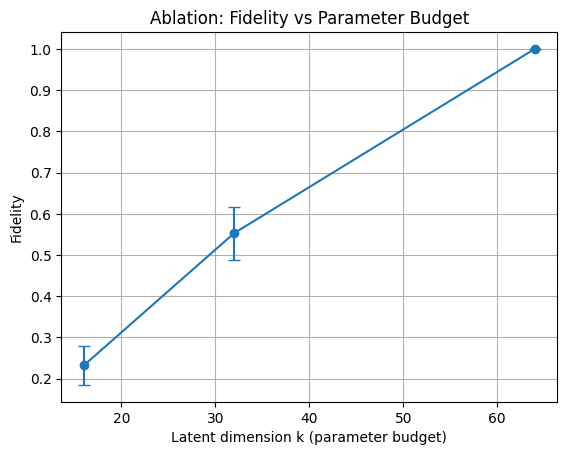

In [10]:
Path("figures").mkdir(exist_ok=True)

plt.figure()
plt.errorbar(
    summary_ablation["latent_dim_k"],
    summary_ablation["mean_fidelity"],
    yerr=summary_ablation["std_fidelity"],
    fmt="o-",
    capsize=4
)
plt.xlabel("Latent dimension k (parameter budget)")
plt.ylabel("Fidelity")
plt.title("Ablation: Fidelity vs Parameter Budget")
plt.grid(True)
plt.savefig("figures/ablation_fidelity_vs_k.png", dpi=200, bbox_inches="tight")
plt.show()


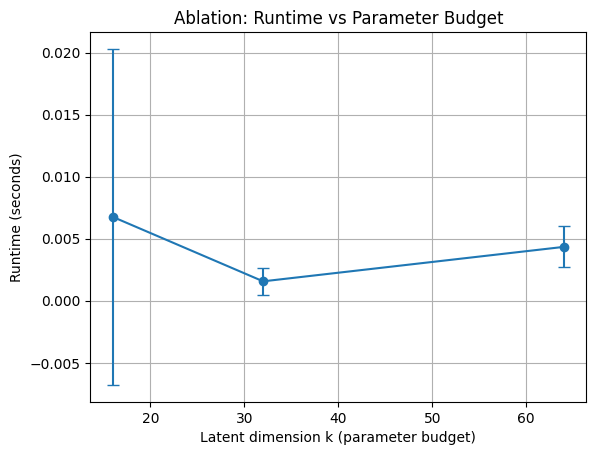

In [11]:
plt.figure()
plt.errorbar(
    summary_ablation["latent_dim_k"],
    summary_ablation["mean_runtime"],
    yerr=summary_ablation["std_runtime"],
    fmt="o-",
    capsize=4
)
plt.xlabel("Latent dimension k (parameter budget)")
plt.ylabel("Runtime (seconds)")
plt.title("Ablation: Runtime vs Parameter Budget")
plt.grid(True)
plt.savefig("figures/ablation_runtime_vs_k.png", dpi=200, bbox_inches="tight")
plt.show()


## Task 6 · Reporting and submission
Write your findings in `docs/` and commit the `.pkl` checkpoints. Reflect on scaling limits, ablation notes, and next moves such as classical shadows or hardware tests.

### Submission checklist
- `.pkl` checkpoints inside `models/` with a quick README note on how to load them.
- Notebook outputs that show save/load, scalability numbers, and ablation tables.
- Plots that highlight fidelity vs qubits and runtime trends.
- A written summary covering method, limits, and future experiments.